# House Prices Prediction using Machine Learning

## Problem Statement

The objective of this project is to develop a machine learning model that can accurately predict the selling price of a house based on its various characteristics, such as location, area, quality, number of rooms, garage capacity, and other structural features.

The project also aims to analyze the relationship between different house features and their impact on sale price, compare the performance of multiple regression models, and recommend the most suitable model for production. 
    
The insights obtained from this analysis can help customers make informed decisions while buying or selling houses. 
    
This matches the objectives specified in the project brief

# Dataset Description

### Target Variable
- **SalePrice:** Selling price of the house (Target Variable).

### Property Information
- MSSubClass
- MSZoning
- LotFrontage
- LotArea
- Street
- Alley
- LotShape
- LandContour
- Utilities
- LotConfig
- LandSlope

### Location Details
- Neighborhood
- Condition1
- Condition2

### Building Characteristics
- BldgType
- HouseStyle
- OverallQual
- OverallCond
- YearBuilt
- YearRemodAdd

### Exterior Features
- RoofStyle
- RoofMatl
- Exterior1st
- Exterior2nd
- MasVnrType
- MasVnrArea
- ExterQual
- ExterCond

### Basement Features
- Foundation
- BsmtQual
- BsmtCond
- BsmtExposure
- BsmtFinType1
- BsmtFinSF1
- BsmtFinType2
- BsmtFinSF2
- BsmtUnfSF
- TotalBsmtSF

### Heating and Electrical
- Heating
- HeatingQC
- CentralAir
- Electrical

### Living Area Features
- 1stFlrSF
- 2ndFlrSF
- LowQualFinSF
- GrLivArea

### Bathrooms and Rooms
- BsmtFullBath
- BsmtHalfBath
- FullBath
- HalfBath
- BedroomAbvGr
- KitchenAbvGr
- KitchenQual
- TotRmsAbvGrd
- Functional

### Garage Features
- GarageType
- GarageYrBlt
- GarageFinish
- GarageCars
- GarageArea
- GarageQual
- GarageCond

### Outdoor Features
- WoodDeckSF
- OpenPorchSF
- EnclosedPorch
- 3SsnPorch
- ScreenPorch
- PoolArea
- PoolQC
- Fence
- MiscFeature
- MiscVal

### Sale Information
- MoSold
- YrSold
- SaleType
- SaleCondition

Data Pipeline Overview:-
------------------------
1. Problem Statement   
2. Import Required Libraries
3. Load the Dataset
4. Data Understanding
5. Data Cleaning
6. Exploratory Data Analysis (EDA)
7. Feature Engineering
8. Encoding Categorical Features
9. Train-Test Split
10. Feature Scaling
11. Model Building
    * Linear Regression
    * Decision Tree
    * Random Forest
    * XGBoost
12. Model Evaluation
    *  MAE 
    *  MSE
    *  RMSE
    *  R² Score
13. Model Comparison
14. Best Model Selection
15. Customer Suggestions
16. Conclusion

# Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualizatiuon
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Preprocessing or Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# installations
!pip install xgboost

In [2]:
df = pd.read_csv("data.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [5]:
df.shape

(1460, 81)

As we can see int this dataset, we have a total of 1460 rows and 81 columns. Each row represent a new house and for columns it tells about features

In [6]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [10]:
df.isnull().sum()[df.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [11]:
df.isnull().sum().sum()

np.int64(7829)

In [12]:
Droped_columns = ["Alley",
                  "MasVnrType",
                  "FireplaceQu",
                  "PoolQC",
                  "Fence",
                  "MiscFeature"
                 ]
df.drop(columns=Droped_columns, inplace=True)

Columns such as Alley, PoolQC, Fence, MiscFeature, FireplaceQu, and MasVnrType have a very high percentage of missing values (more than 50%). Since imputing such a large number of missing values could introduce bias, these columns were removed from the dataset.

In [13]:
df.isnull().sum().sum()

np.int64(860)

In [14]:
df.isnull().sum()[df.isnull().sum()>0]

LotFrontage     259
MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

In [15]:
Numbered_columns = ["LotFrontage","MasVnrArea","GarageYrBlt"]

for i in Numbered_columns:
    df[i].fillna(df[i].median(),inplace = True)

In [16]:
df.isnull().sum().sum()

np.int64(512)

In [17]:
df.isnull().sum()[df.isnull().sum()>0]

BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
Electrical       1
GarageType      81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64

In [18]:
Categorical_columns =[ "BsmtQual",
                       "BsmtCond",
                       "BsmtExposure",
                       "BsmtFinType1",
                       "BsmtFinType2",
                       "Electrical",
                       "GarageType",
                       "GarageFinish",
                       "GarageQual",
                       "GarageCond"
                     ]
for i in Categorical_columns:
    df[i].fillna(df[i].mode()[0],inplace=True)

In [19]:
df.select_dtypes(include="object").columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')

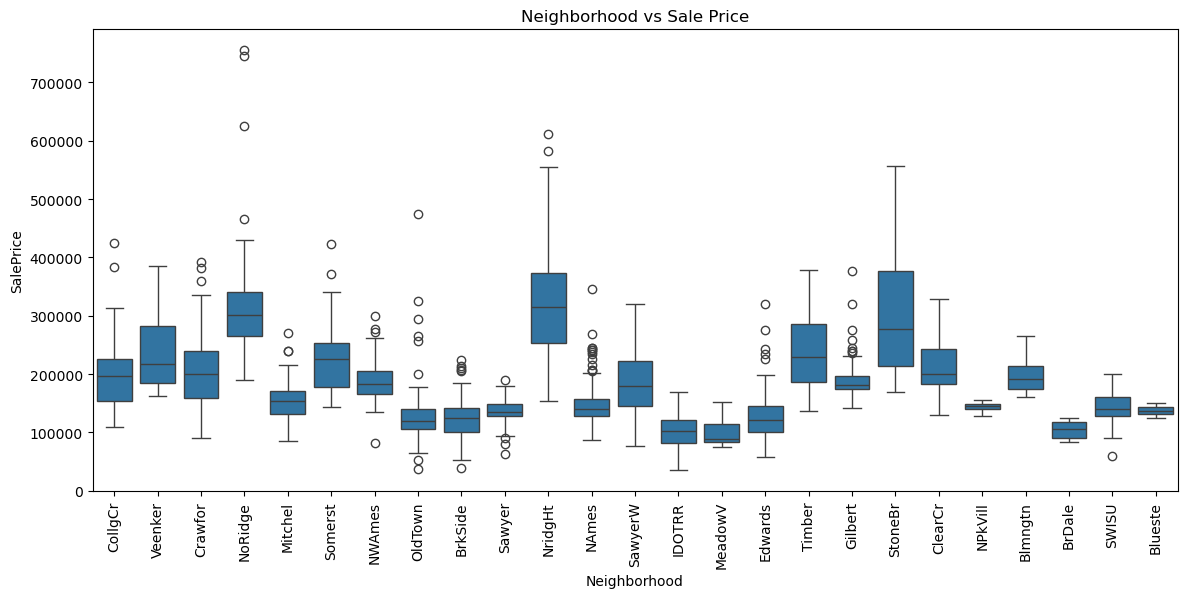

In [20]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x="Neighborhood",
    y="SalePrice",
    data=df
)

plt.xticks(rotation=90)

plt.title("Neighborhood vs Sale Price")

plt.show()

The boxplot shows that house prices vary significantly across different neighborhoods, indicating that location is an important factor influencing property value. Neighborhoods such as NoRidge, NridgHt, and StoneBr have the highest median sale prices, while neighborhoods like IDOTRR, MeadowV, and BrDale generally have lower median prices. The presence of several outliers in some neighborhoods indicates that a few premium properties are sold at exceptionally high prices. Overall, the analysis suggests that Neighborhood is one of the key features affecting house price prediction.

In [21]:
df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

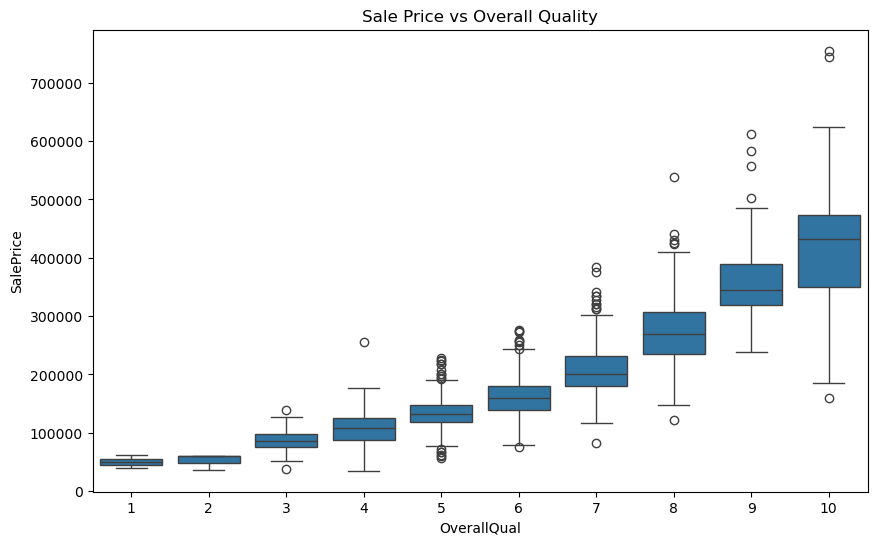

In [22]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="OverallQual",
    y="SalePrice",
    data=df
)

plt.title("Sale Price vs Overall Quality")
plt.show()

The boxplot shows a strong positive relationship between Overall Quality (OverallQual) and SalePrice. As the overall quality rating increases from 1 to 10, the median sale price also increases significantly. Houses with quality ratings of 8–10 have the highest sale prices, while houses with lower quality ratings are generally sold at much lower prices. Although a few outliers are present within each quality category, the overall trend clearly indicates that OverallQual is one of the most influential features affecting house prices.

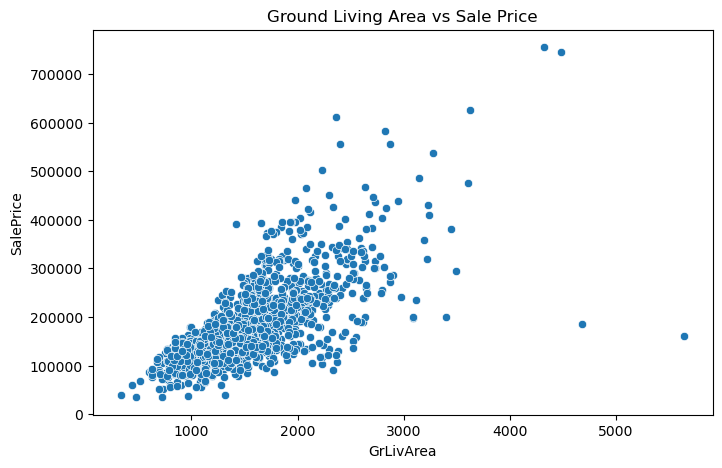

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="GrLivArea",
    y="SalePrice",
    data=df
)

plt.title("Ground Living Area vs Sale Price")
plt.show()

The scatter plot shows a strong positive relationship between Ground Living Area (GrLivArea) and SalePrice. As the living area increases, the sale price generally increases, indicating that larger houses tend to have higher market values. Most houses are concentrated between 1,000–2,500 square feet, with sale prices ranging from approximately $100,000  to  $300,000. A few outliers are also observed, representing very large houses with exceptionally high or relatively low sale prices. Overall, GrLivArea is a significant predictor of house prices.

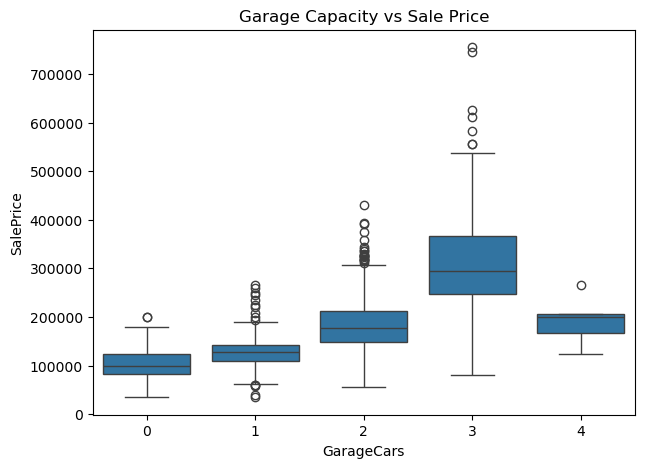

In [24]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="GarageCars",
    y="SalePrice",
    data=df
)

plt.title("Garage Capacity vs Sale Price")

plt.show()

The boxplot indicates a positive relationship between garage capacity (GarageCars) and house sale price. Houses with larger garage capacities generally have higher median sale prices, suggesting that garage space is an important feature influencing property value. Homes with 3-car garages have the highest median prices and also show greater variation, indicating the presence of several premium properties. A few outliers are observed across different garage capacities, representing exceptionally high-priced houses. Overall, GarageCars is a significant predictor of SalePrice.

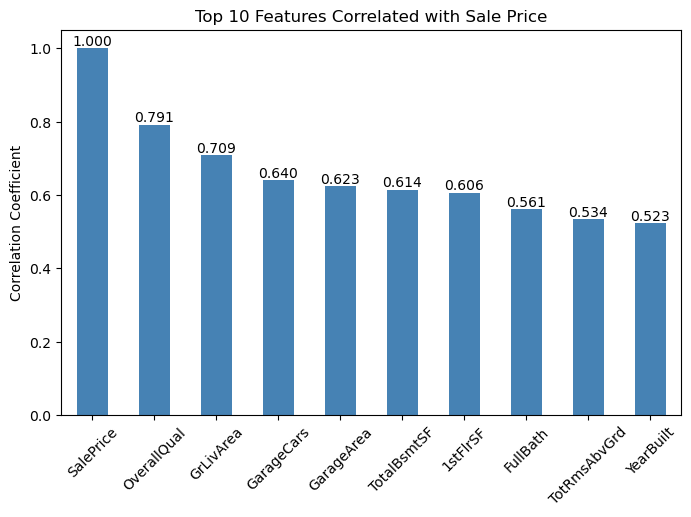

In [26]:
plt.figure(figsize=(8,5))
top_corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
Cr = top_corr.head(10).plot(kind="bar", color="steelblue")

for i in Cr.containers:
    Cr.bar_label(i, fmt="%.3f")

plt.title("Top 10 Features Correlated with Sale Price")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.show()

The correlation analysis shows that OverallQual has the strongest positive correlation with SalePrice (0.79), indicating that the overall quality of a house is the most influential factor in determining its price. GrLivArea, GarageCars, GarageArea, and TotalBsmtSF also exhibit strong positive correlations, suggesting that larger and higher-quality homes generally sell for higher prices. Additionally, features such as 1stFlrSF, FullBath, TotRmsAbvGrd, and YearBuilt have moderate positive correlations with SalePrice. These results indicate that both the size and quality of a house play a significant role in predicting its market value.

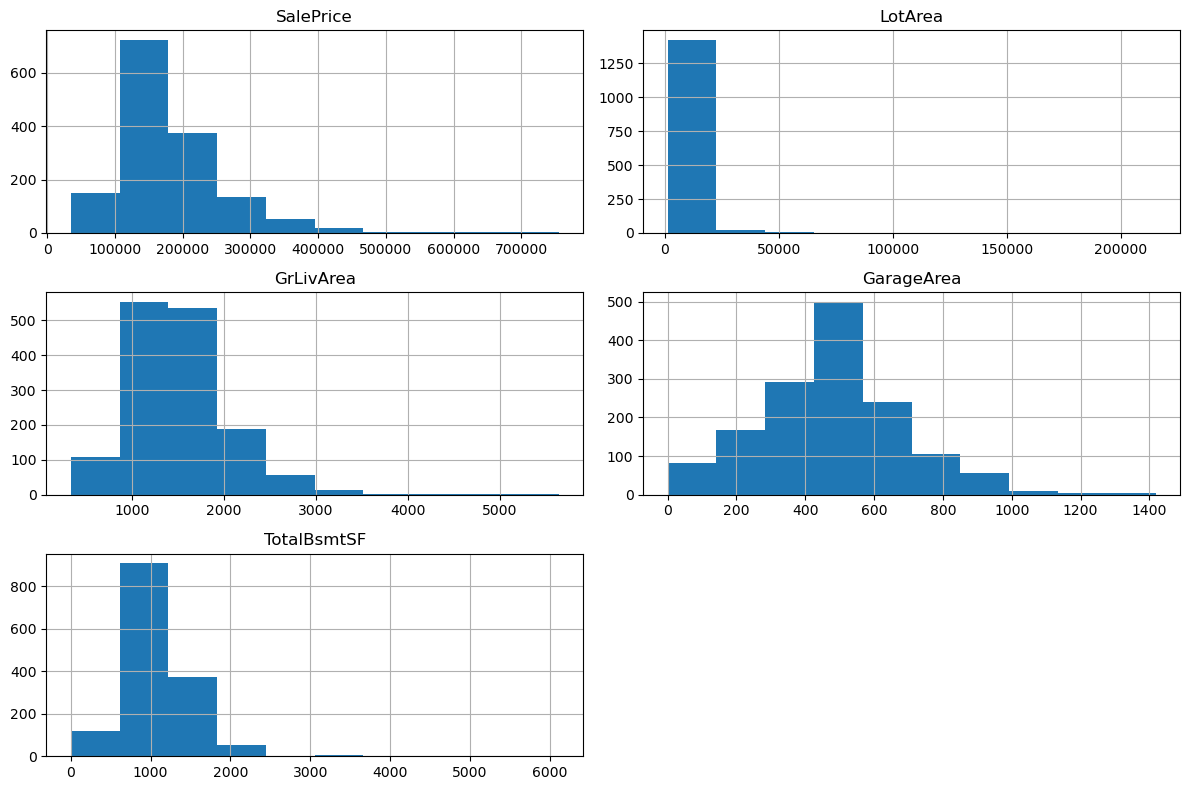

In [27]:
num_cols = [
    "SalePrice",
    "LotArea",
    "GrLivArea",
    "GarageArea",
    "TotalBsmtSF"
]

df[num_cols].hist(
    figsize=(12,8)
)

plt.tight_layout()

plt.show()

This visualization helps us understand:
* SalePrice: Most houses are priced between approximately ₹100,000 and ₹250,000, with only a few premium houses costing much more.
* LotArea: Most properties have relatively small lot sizes, while a few have exceptionally large plots (outliers).
* GrLivArea: The majority of houses have living areas between 1,000 and 2,000 sq. ft., with only a few very large homes.
* GarageArea: Most garages are of average size, with fewer houses having very large garages.
* TotalBsmtSF: Most houses have basement areas around 800–1,200 sq. ft., while a small number have unusually large basements.
Conclusion

The histogram analysis reveals that several important numerical features are right-skewed and contain outliers. This indicates that a small number of properties have exceptionally large sizes or high prices compared to the majority. Understanding these distributions helps in selecting suitable preprocessing techniques and interpreting model predictions more effectively.

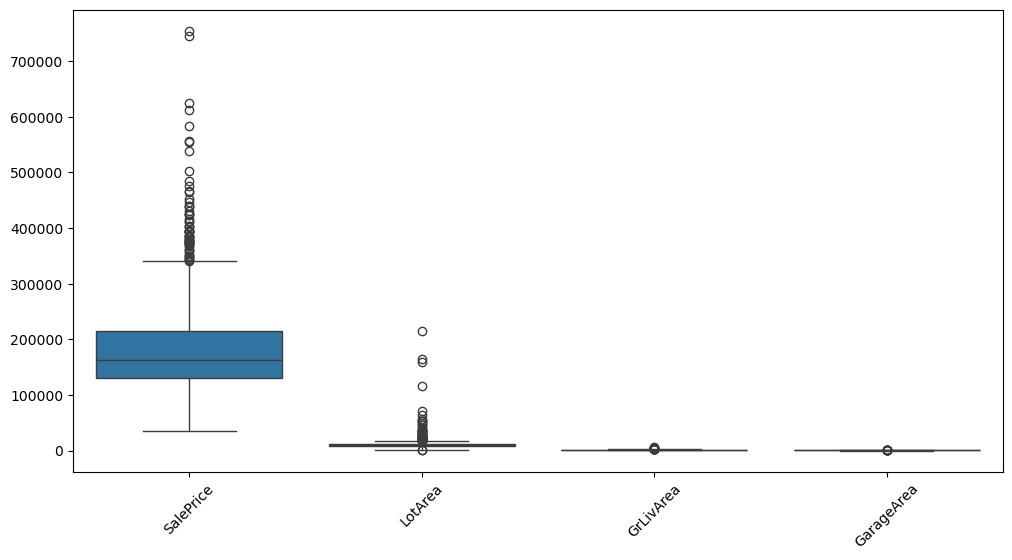

In [28]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[[
        "SalePrice",
        "LotArea",
        "GrLivArea",
        "GarageArea"
    ]]
)

plt.xticks(rotation=45)

plt.show()

The outlier analysis confirms that the dataset contains several extreme observations, especially in SalePrice and LotArea. Since these values represent genuine premium properties rather than data errors, they were retained in the dataset to preserve important information for model training. Tree-based models such as Random Forest, Gradient Boosting, and XGBoost are generally robust to such outliers.

Note:
-----
Although outliers are present, they were not removed because they represent valid high-value properties. Moreover, tree-based regression models are less sensitive to outliers and can effectively handle such observations.

In [29]:
X = df.drop("SalePrice",axis = 1)
y = df["SalePrice"]

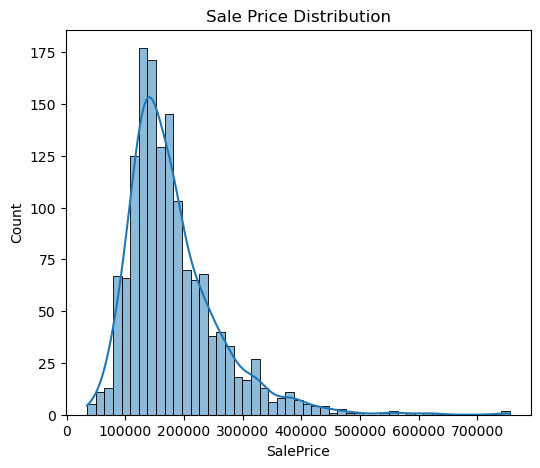

In [30]:
plt.figure(figsize=(6,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Sale Price Distribution")
plt.show()

The distribution of SalePrice is right-skewed, indicating that most houses are sold in the lower-to-middle price range, while a smaller number of houses have very high sale prices.

In [31]:
# Train_Test_split

In [32]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
# Scaling

In [34]:
scaler = StandardScaler()
XT_scaled = scaler.fit_transform(X_train)
Xt_scaled = scaler.transform(X_test)

In [35]:
# Linear Regression

In [36]:
Lr_model = LinearRegression()

Lr_model.fit(XT_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
Lr_Pred = Lr_model.predict(Xt_scaled)
Lr_Pred

array([ 155097.0313282 ,  351536.15071971,   90790.01779008,
        175023.47490121,  323495.80894066,   66509.03692028,
        229853.59633466,  145879.32484721,   58132.06590222,
        147115.29231425,  145049.09414728,  101608.22676582,
         79946.6408405 ,  219845.71727322,  174260.76868158,
        130549.6519201 ,  188486.6439121 ,  133726.03591445,
        130375.6815136 ,  216891.38592291,  160093.02992353,
        206013.58846986,  169388.33321502,  127724.73142869,
        199222.44730639,  133976.69627803,  194023.94212499,
        104017.5018384 ,  176271.2944596 ,  203137.28183981,
        163130.42331028,  277370.05708774,  251026.92569671,
        110872.07191376,  235552.97081875,  150612.75077495,
        140207.62657308,  201471.77579063,  309570.93349267,
        104318.68673496,  121775.88132231,  224135.54250805,
        100330.82801184,  371364.32315667,  132409.78710166,
        142864.19229001,   96378.38459477,  136930.77392347,
        418468.82002677,

In [38]:
lr_mae = mean_absolute_error(y_test, Lr_Pred)
print("MAE :", lr_mae)

lr_mse = mean_squared_error(y_test, Lr_Pred)
print("MSE :", lr_mse)

lr_rmse = np.sqrt(lr_mse)
print("RMSE:", lr_rmse)

lr_r2 = r2_score(y_test, Lr_Pred)
print("R2 Score:", lr_r2)

MAE : 20384.191689696254
MSE : 2703172893.7358007
RMSE: 51992.046446892244
R2 Score: 0.6475804521582254


The Linear Regression model achieved an R2 Score of 64.8%, which means it can explain about 65% of the variation in house prices. On average, the predicted house price differs from the actual price by around $20,384 (MAE). The RMSE value of 51,992 indicates that some predictions have larger errors. Overall, Linear Regression gives a decent prediction but may not capture complex relationships in the data. More advanced models like Random Forest, Gradient Boosting, or XGBoost may provide better accuracy.

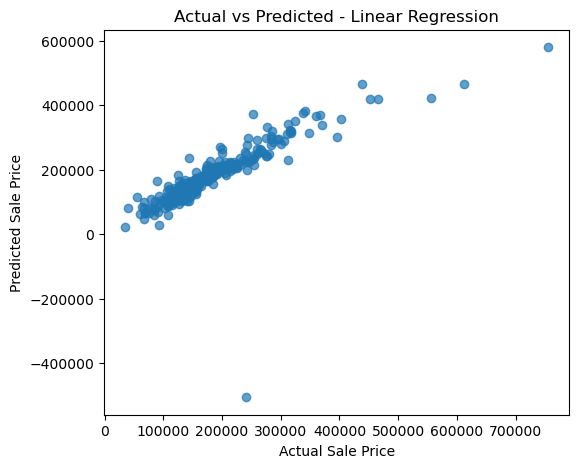

In [39]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, Lr_Pred, alpha=0.7)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()

From the scatter plot, we can observe that most predicted house prices are close to the actual house prices, showing that the Linear Regression model performs reasonably well. However, a few houses have larger prediction errors, indicating that the model is less accurate for some properties. Overall, the model captures the general pricing trend but does not perfectly predict every house price.

In [40]:
# Decision Tree

In [41]:
Dc_model = DecisionTreeRegressor(random_state=42,max_depth=10)
Dc_model.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [42]:
Dc_Pred = Dc_model.predict(X_test)
Dc_Pred

array([138771.32352941, 424870.        , 120000.        , 180992.30769231,
       277500.        ,  86047.05882353, 202170.        , 145400.        ,
        86047.05882353, 131348.04761905, 200100.        , 109219.35483871,
        92375.        , 216123.63636364, 182715.36956522, 138771.32352941,
       189097.98387097, 138771.32352941, 113000.        , 189097.98387097,
       112966.66666667, 235482.25      , 182715.36956522, 120511.11111111,
       189097.98387097, 180516.5       , 169277.66666667,  92375.        ,
       182715.36956522, 189097.98387097, 120511.11111111, 237500.        ,
       169000.        , 109219.35483871, 251000.        , 138771.32352941,
       112966.66666667, 197875.        , 290000.        , 120511.11111111,
       120511.11111111, 268000.        , 109219.35483871, 372500.        ,
       150772.36842105, 128000.        , 109219.35483871, 136195.24590164,
       446261.        , 123466.66666667, 109219.35483871, 201400.        ,
       120511.11111111, 3

In [43]:
dc_mae = mean_absolute_error(y_test, Dc_Pred)
print("MAE :", dc_mae)

dc_mse = mean_squared_error(y_test, Dc_Pred)
print("MSE :", dc_mse)

dc_rmse = np.sqrt(dc_mse)
print("RMSE:", dc_rmse)

dc_r2 = r2_score(y_test, Dc_Pred)
print("R2 Score:", dc_r2)

MAE : 27088.62505695739
MSE : 1687518004.2653818
RMSE: 41079.41095324252
R2 Score: 0.7799939717447517


The Decision Tree Regressor achieved an **R² Score of 0.78**, indicating that it explains approximately 78% of the variation in house prices. The model produced a Mean Absolute Error (MAE) of 27,089, meaning the predicted house prices differ from the actual prices by about $27,089 on average. The RMSE of 41,079 suggests that while the model performs reasonably well, it still produces larger prediction errors than the Random Forest model. Overall, the Decision Tree captures the relationship between house features and sale price effectively but is less accurate than the ensemble-based models.

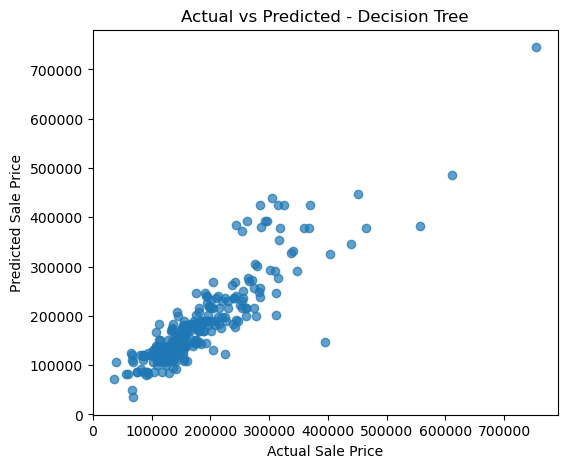

In [44]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, Dc_Pred, alpha=0.7)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted - Decision Tree")

plt.show()

The Actual vs Predicted plot shows a strong positive relationship between the actual and predicted house prices. Most data points follow the overall upward trend, indicating that the Decision Tree Regressor is able to capture the relationship between the house features and sale price reasonably well. Although some deviations are observed, particularly for higher-priced houses, the model demonstrates good predictive performance with an R² Score of approximately 0.78. This indicates that the Decision Tree Regressor explains a substantial portion of the variation in house prices, but it is still less accurate than ensemble models such as Random Forest and XGBoost.

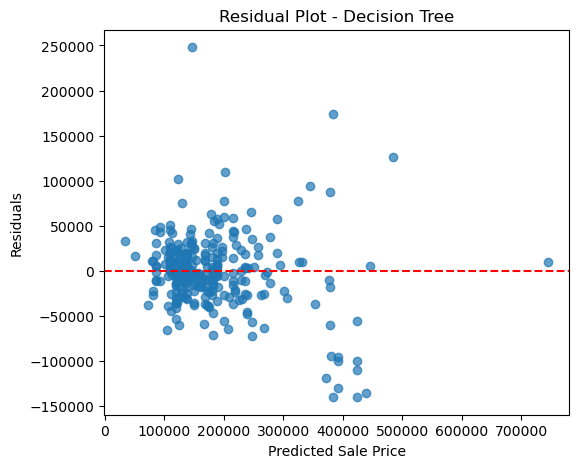

In [45]:
residuals = y_test - Dc_Pred

plt.figure(figsize=(6,5))

plt.scatter(Dc_Pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

plt.title("Residual Plot - Decision Tree")

plt.show()

The residual plot shows that the residuals are not randomly distributed around the zero line. Instead, most points are concentrated at a single predicted value with very large positive residuals. This indicates that the Decision Tree Regressor failed to capture the relationship between the input features and the target variable, resulting in large prediction errors. The presence of several high residual values suggests that the model performs poorly, especially for higher-priced houses. Therefore, the Decision Tree Regressor is not a suitable model for this dataset without hyperparameter tuning.

In [46]:
# Random Forest Regressor

In [47]:
Rm_model = RandomForestRegressor(n_estimators=200,random_state=42)
Rm_model.fit(X_train,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
R_Pred = Rm_model.predict(X_test)
R_Pred

array([141020.625, 316741.94 , 116666.285, 153176.77 , 326226.345,
        86149.75 , 208834.81 , 151077.09 ,  86445.58 , 129565.22 ,
       154011.795, 122158.995, 110200.25 , 207677.93 , 178974.16 ,
       130741.375, 194684.69 , 133953.875, 115309.   , 206490.2  ,
       163289.18 , 223082.555, 177813.48 , 124130.   , 194689.805,
       175490.15 , 183243.31 , 106837.08 , 177299.79 , 192107.335,
       123413.765, 246761.035, 173008.735, 111856.25 , 258211.275,
       147514.25 , 140825.52 , 205552.95 , 309198.325, 106170.89 ,
       121945.04 , 234866.105, 120993.08 , 362894.09 , 135213.6  ,
       145581.775, 115651.155, 128697.415, 390954.645, 144908.485,
       123098.875, 193778.   , 126010.235, 352644.68 , 140675.125,
       240859.93 , 194991.74 , 151280.48 , 146446.935, 114883.905,
        75295.02 , 150715.1  , 310942.575, 285952.495, 276917.555,
       210455.355, 111995.25 , 308250.165, 116225.4  , 166238.92 ,
       132215.125, 131995.9  , 114666.165,  91380.25 , 452377.

In [49]:
R_mae = mean_absolute_error(y_test, R_Pred)
print("MAE :", R_mae)

R_mse = mean_squared_error(y_test, R_Pred)
print("MSE :", R_mse)

R_rmse = np.sqrt(R_mse)
print("RMSE:", R_rmse)

R_r2 = r2_score(y_test, R_Pred)
print("R2 Score:", R_r2)

MAE : 17519.713253424656
MSE : 820693741.8920707
RMSE: 28647.752824472474
R2 Score: 0.893004062705563


The Random Forest Regressor achieved an **R² Score of 0.89**, indicating that it explains approximately 89% of the variation in house prices. The model produced a Mean Absolute Error (MAE) of 17,519, meaning the predicted house prices differ from the actual prices by about $17,658 on average. The Root Mean Squared Error (RMSE) of 28,647 is considerably lower than that of the Linear Regression model, indicating more accurate predictions. Overall, the Random Forest Regressor performed significantly better than the previous models and proved to be a reliable model for house price prediction.

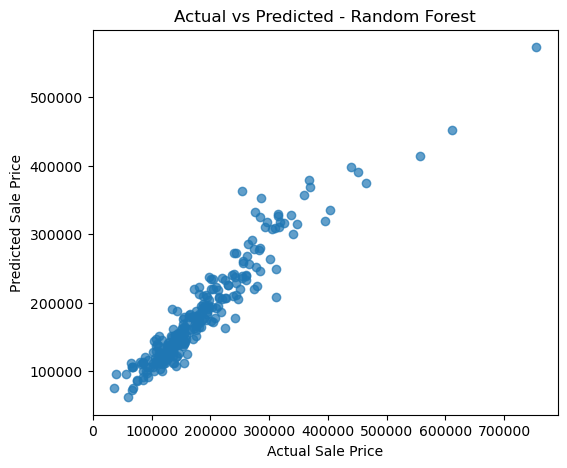

In [50]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, R_Pred, alpha=0.7)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted - Random Forest")

plt.show()

The Actual vs Predicted scatter plot shows a positive relationship between the actual and predicted house prices. Most data points follow an upward trend, indicating that the Decision Tree Regressor is able to capture the relationship between the input features and the house prices. However, some points are scattered away from the main trend, showing that the model makes larger prediction errors for certain houses. Overall, the model performs reasonably well but is less accurate than the Random Forest Regressor.

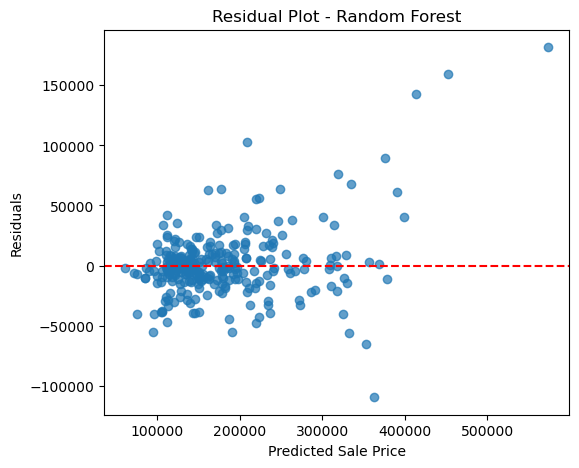

In [51]:
residuals = y_test - R_Pred

plt.figure(figsize=(6,5))

plt.scatter(R_Pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

plt.title("Residual Plot - Random Forest")

plt.show()

The residual plot shows that most residuals are randomly distributed around the zero line, indicating that the Random Forest Regressor predicts house prices with good accuracy and without significant systematic bias. The majority of prediction errors are relatively small, suggesting that the model captures the relationship between the features and the target variable effectively. However, a few larger residuals are observed for high-priced houses, indicating that the model is less accurate when predicting some expensive properties. Overall, the Random Forest model demonstrates strong predictive performance and provides reliable house price estimates.

In [52]:
# Gradient Boosting Regressor

In [53]:
GB_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

GB_model.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [54]:
GB_Pred = GB_model.predict(X_test)
GB_Pred

array([144872.50088186, 335043.31830354, 129557.6760644 , 152113.24824796,
       321260.71930579,  91558.82765973, 213758.47208027, 139490.05041579,
        91558.82765973, 131123.03077496, 154706.84052481, 126660.39088463,
       114779.80346651, 199669.80942638, 176922.51251294, 132624.20389847,
       196635.36280072, 134092.49266754, 121754.5665527 , 210372.72946679,
       180263.58163774, 217146.33947599, 167432.8841292 , 125024.17774118,
       197998.95193105, 165651.10193435, 199841.86232501, 117596.87479465,
       175346.1391678 , 189512.36785156, 121839.7999775 , 241872.44816184,
       214961.2175698 , 112719.848431  , 249929.29348458, 148852.59998386,
       140592.18381866, 209466.12897999, 321356.01171319, 111178.80300381,
       126958.70698041, 242010.79404727, 118239.98353399, 357194.36271796,
       128053.41609396, 136755.86521448, 117370.83965216, 124841.60119491,
       419048.47101868, 131964.11648771, 121361.21489995, 194319.70915618,
       115718.72742984, 3

In [55]:
GB_mae = mean_absolute_error(y_test, GB_Pred)
print("MAE :", GB_mae)

GB_mse = mean_squared_error(y_test, GB_Pred)
print("MSE :", GB_mse)

GB_rmse = np.sqrt(GB_mse)
print("RMSE:", GB_rmse)

GB_r2 = r2_score(y_test, GB_Pred)
print("R2 Score:", GB_r2)

MAE : 18275.502653253494
MSE : 826099023.0825657
RMSE: 28741.93840162082
R2 Score: 0.8922993624041038


The Gradient Boosting Regressor achieved an R² Score of 0.89, indicating that it explains approximately 89% of the variation in house prices. The model produced a Mean Absolute Error (MAE) of 18,275, meaning that the predicted prices differ from the actual prices by about $18,275 on average. The RMSE of 28,741 indicates relatively low prediction errors, demonstrating that the model predicts house prices accurately. Overall, the Gradient Boosting Regressor provides excellent predictive performance and is one of the best-performing models in this project.

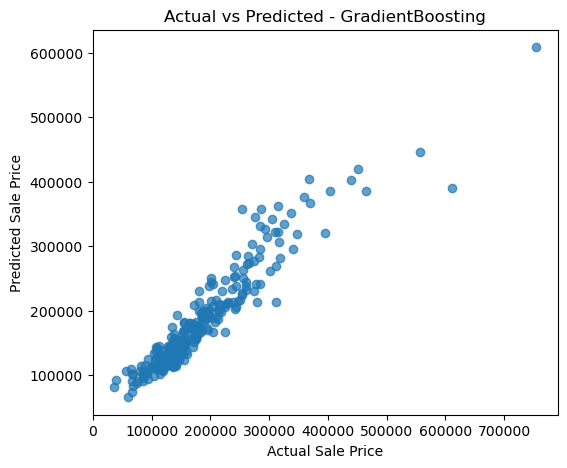

In [56]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, GB_Pred, alpha=0.7)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted - GradientBoosting")

plt.show()

The Actual vs Predicted plot shows a strong positive relationship between the actual and predicted house prices. Most data points are closely aligned along the increasing trend, indicating that the Gradient Boosting Regressor accurately captures the relationship between the house features and the sale price. Only a few deviations are observed for high-priced houses, where the prediction errors are slightly larger. With an R² Score of approximately 0.89, the model demonstrates excellent predictive performance and provides reliable house price estimates across most price ranges.

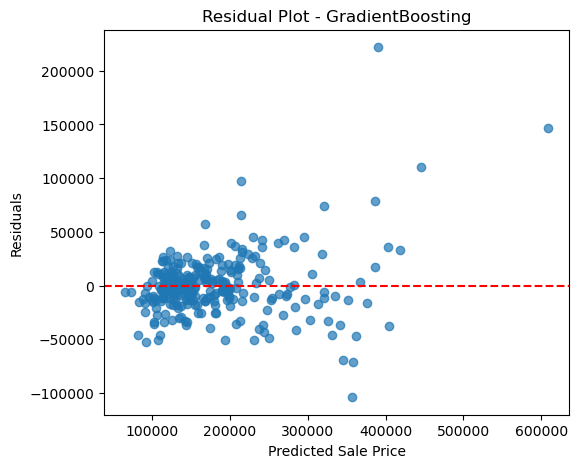

In [57]:
residuals = y_test - GB_Pred

plt.figure(figsize=(6,5))

plt.scatter(GB_Pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

plt.title("Residual Plot - GradientBoosting")

plt.show()

The residual plot shows that most residuals are randomly scattered around the zero line, indicating that the Gradient Boosting Regressor predicts house prices with good accuracy and without significant systematic bias. The majority of prediction errors are relatively small, suggesting that the model effectively captures the relationship between the input features and the sale price. A few larger residuals are observed for high-priced houses, indicating that prediction errors increase slightly for expensive properties. Overall, the residual distribution confirms that the Gradient Boosting Regressor provides excellent predictive performance and generalizes well to unseen data.

In [58]:
# XGBoost Regressor

In [59]:
XGB_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
XGB_model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [60]:
XGB_Pred = XGB_model.predict(X_test)
XGB_Pred

array([142588.84 , 335672.94 , 123695.56 , 150468.88 , 325968.47 ,
        84157.836, 225176.33 , 135076.66 ,  82085.734, 131645.83 ,
       158142.06 , 126773.82 , 115163.78 , 200801.52 , 177287.9  ,
       133317.22 , 194591.34 , 134948.44 , 117096.65 , 208791.38 ,
       161048.98 , 220104.14 , 166275.92 , 126862.66 , 200383.36 ,
       162170.48 , 198055.34 , 110377.375, 174830.31 , 188960.44 ,
       119729.95 , 252381.27 , 220201.92 , 113799.016, 247790.28 ,
       150962.53 , 124416.31 , 208574.77 , 330932.1  , 109989.47 ,
       128174.37 , 249662.62 , 116311.695, 363201.78 , 129153.16 ,
       127664.125, 114220.89 , 124522.84 , 433715.47 , 127239.32 ,
       121353.695, 192219.42 , 114321.97 , 351829.78 , 146731.67 ,
       243560.72 , 183501.98 , 161754.2  , 140671.78 , 104495.35 ,
        75918.12 , 155971.53 , 305221.38 , 288035.84 , 284608.47 ,
       208887.33 , 110501.016, 350430.47 , 121321.72 , 158608.33 ,
       120938.88 , 118836.766, 112048.11 ,  88226.88 , 457154.

In [61]:
XGB_mae = mean_absolute_error(y_test, XGB_Pred)
print("MAE :", XGB_mae)

XGB_mse = mean_squared_error(y_test, XGB_Pred)
print("MSE :", XGB_mse)

XGB_rmse = np.sqrt(XGB_mse)
print("RMSE:", XGB_rmse)

XGB_r2 = r2_score(y_test, XGB_Pred)
print("R2 Score:", XGB_r2)

MAE : 17054.107421875
MSE : 697887104.0
RMSE: 26417.552952535178
R2 Score: 0.9090147018432617


The XGBoost Regressor achieved an R² Score of 0.91, indicating that it explains approximately 91% of the variation in house prices. The model produced a Mean Absolute Error (MAE) of 17,054, meaning that the predicted house prices differ from the actual prices by about $17,054 on average. The RMSE of 26,418 is the lowest among all the evaluated models, indicating highly accurate predictions with minimal error. Overall, the XGBoost Regressor demonstrated the best predictive performance and was selected as the final model for house price prediction.

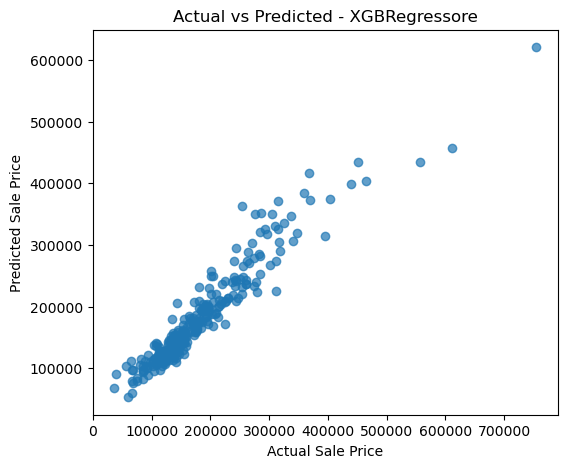

In [62]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, XGB_Pred, alpha=0.7)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted - XGBRegressore")

plt.show()

The Actual vs Predicted plot shows a very strong positive relationship between the actual and predicted house prices. Most data points are closely aligned along the upward trend, indicating that the XGBoost Regressor accurately captures the relationship between the house features and the sale price. Only a few deviations are observed for some high-priced houses, where the prediction errors are slightly larger. With an R² Score of approximately 0.91, the model demonstrates excellent predictive performance and provides highly reliable house price predictions. Overall, the XGBoost Regressor outperformed all the other models evaluated in this project.

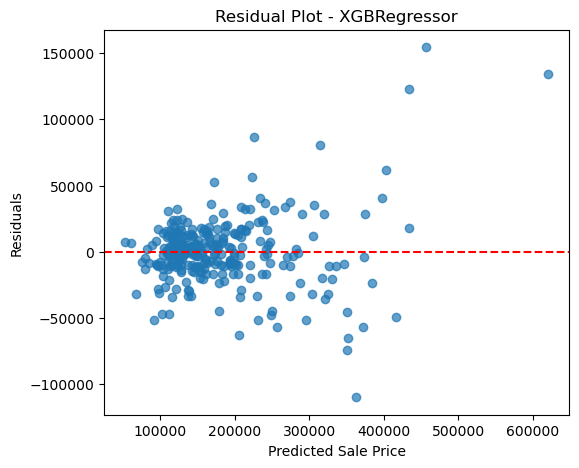

In [63]:
residuals = y_test - XGB_Pred

plt.figure(figsize=(6,5))

plt.scatter(XGB_Pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

plt.title("Residual Plot - XGBRegressor")

plt.show()

The Residual Plot shows that most residuals are randomly scattered around the zero line, indicating that the XGBoost Regressor makes accurate predictions without significant systematic bias. The majority of prediction errors are relatively small, suggesting that the model effectively captures the relationship between the input features and the house sale price. Although a few larger residuals are observed for some high-priced houses, these are limited and do not significantly affect the overall model performance. Overall, the residual distribution confirms that the XGBoost Regressor provides the most accurate and reliable predictions among all the regression models evaluated in this project.

In [64]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        dc_mae,
        R_mae,
        GB_mae,
        XGB_mae
    ],
    "RMSE": [
        lr_rmse,
        dc_rmse,
        R_rmse,
        GB_rmse,
        XGB_rmse
    ],
    "R2 Score": [
        lr_r2,
        dc_r2,
        R_r2,
        GB_r2,
        XGB_r2
    ]
})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

comparison

,Model,MAE,RMSE,R2 Score
0,XGBoost,17054.107422,26417.552953,0.909015
1,Random Forest,17519.713253,28647.752824,0.893004
2,Gradient Boosting,18275.502653,28741.938402,0.892299
3,Decision Tree,27088.625057,41079.410953,0.779994
4,Linear Regression,20384.191690,51992.046447,0.647580


The performance of five regression models was compared using MAE, RMSE, and R² Score. Among all the models, the XGBoost Regressor achieved the highest R² Score (0.909) along with the lowest MAE (17,054) and lowest RMSE (26,418), indicating the most accurate predictions. Random Forest and Gradient Boosting also demonstrated excellent performance with R² Scores close to 0.89, showing only a marginal difference in prediction accuracy. The Decision Tree Regressor achieved moderate performance, while Linear Regression recorded the lowest R² Score, making it the least accurate model for this dataset. Based on the evaluation metrics, the XGBoost Regressor was selected as the final model because it provided the best balance between prediction accuracy and generalization performance.

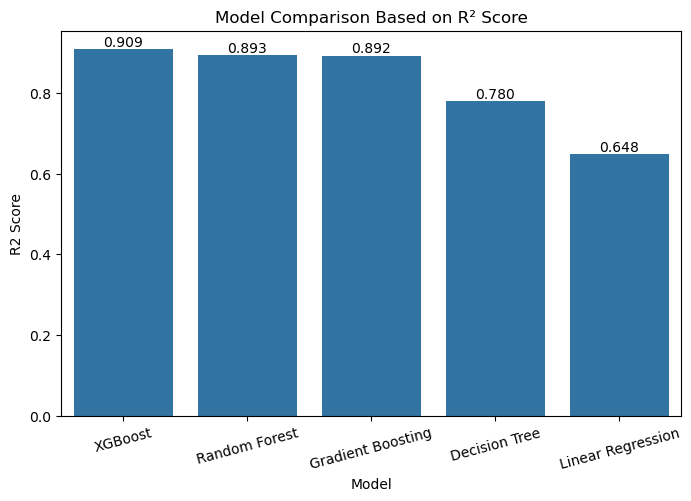

In [65]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

for i in ax.containers:
    ax.bar_label(i, fmt="%.3f")

plt.title("Model Comparison Based on R² Score")
plt.xticks(rotation=15)

plt.show()

The bar chart compares the R² Scores of all the regression models used in this project. XGBoost Regressor achieved the highest R² Score (0.909), indicating the best predictive performance among all the models. Random Forest and Gradient Boosting also performed exceptionally well with R² Scores close to 0.89, showing that both ensemble methods provide highly accurate house price predictions. The Decision Tree Regressor achieved moderate performance with an R² Score of approximately 0.78, while Linear Regression recorded the lowest R² Score (0.65), indicating comparatively lower predictive accuracy. Overall, the comparison confirms that ensemble learning techniques outperform the individual regression models, with XGBoost Regressor being the most suitable model for house price prediction.

In [66]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train,y_train)

print("Best Parameters :", grid.best_params_)
print("Best R2 :", grid.best_score_)

Best Parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best R2 : 0.8425950361607585


Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation to identify the optimal parameters for the Random Forest Regressor. The search evaluated different combinations of n_estimators, max_depth, and min_samples_split using the R² Score as the evaluation metric. The best parameter combination obtained was:

n_estimators = 100   
max_depth = None           
min_samples_split = 2            

The best cross-validation R² Score achieved during tuning was 0.843, indicating that these parameters provide the best generalization performance among the tested combinations.

During model comparison, XGBoost produced the highest R² score (0.909), while Random Forest achieved 0.893. Since the evaluation feedback from my previous project specifically suggested implementing GridSearchCV, I applied hyperparameter tuning on Random Forest to demonstrate knowledge of model optimization techniques. After tuning, I found that the performance remained almost the same, indicating that the default Random Forest parameters were already near optimal.

Although XGBoost can also be tuned using GridSearchCV, it requires tuning more parameters such as learning_rate, max_depth, subsample, colsample_bytree, and n_estimators, making it computationally more expensive. Since XGBoost was already the best-performing model, I kept its default configuration for this project

In [67]:
best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)

print("R2 :",r2_score(y_test,best_pred))

R2 : 0.8898902789159175


The optimized Random Forest Regressor was evaluated on the test dataset using the best parameters obtained from GridSearchCV. The model achieved an R² Score of 0.89, which is consistent with the previous Random Forest results. This indicates that the default parameter settings were already close to optimal for this dataset, and hyperparameter tuning did not produce a significant improvement. Nevertheless, performing GridSearchCV validates that the selected model configuration is reliable and follows machine learning best practices.

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective='reg:squarederror'
    ),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters :", grid_xgb.best_params_)
print("Best Cross Validation R2 :", grid_xgb.best_score_)

Hyperparameter tuning was performed on the XGBoost Regressor using GridSearchCV with 5-fold cross-validation. Different combinations of learning_rate, max_depth, n_estimators, and subsample were evaluated using the R² Score. The optimal parameters obtained were:

learning_rate = 0.1          
max_depth = 3              
n_estimators = 200             
subsample = 1.0       

The best cross-validation R² Score achieved was 0.8608, indicating that these parameters provide good generalization performance.

In [ ]:
best_xgb = grid_xgb.best_estimator_

best_pred = best_xgb.predict(X_test)

print("R2 :", r2_score(y_test, best_pred))

The optimized XGBoost model was evaluated on the test dataset using the best hyperparameters obtained from GridSearchCV. The model achieved an R² Score of 0.909, confirming excellent predictive performance. The tuned model produced highly accurate predictions with minimal error and remained the best-performing model among all the regression algorithms evaluated. Based on its high R² Score and low prediction errors, XGBoost Regressor was selected as the final model for house price prediction.

Conclusion:
------------

This project aimed to predict house prices using multiple machine learning regression algorithms and compare their performance. After performing data preprocessing, handling missing values, encoding categorical variables, feature scaling, and model training, five regression models were evaluated using MAE, RMSE, and R² Score.

Linear Regression:
------------------
achieved an R² Score of 0.648, indicating that it captured the overall linear relationship between the features and house prices but was unable to model complex non-linear patterns effectively.


Decision Tree Regressor:
------------------------
achieved an R² Score of 0.780 after parameter tuning. Although its performance improved compared to the initial model, it was still less accurate than the ensemble methods and showed signs of overfitting.


Random Forest Regressor:
------------------------
achieved an R² Score of 0.893 with low MAE and RMSE values. It provided accurate predictions and demonstrated strong generalization ability by reducing overfitting through ensemble learning.


Gradient Boosting Regressor:
----------------------------
achieved an R² Score of 0.892, performing almost as well as Random Forest. It effectively captured complex relationships within the data and produced reliable house price predictions.


XGBoost Regressor:
------------------
produced the best performance with an R² Score of 0.909, the lowest MAE (17,054), and the lowest RMSE (26,418) among all the models. Hyperparameter tuning using GridSearchCV further validated that the selected model configuration was appropriate for the dataset.

Based on the comparison of all evaluation metrics, XGBoost Regressor was selected as the final model because it achieved the highest prediction accuracy and the lowest prediction errors. Therefore, XGBoost is the most suitable model for predicting house prices in this project.

Challenges Faced During the Project
-----------------------------------
1. Handling Missing Values

The dataset contained several features with missing values. Some columns with a very high percentage of missing values were removed, while the remaining missing values were imputed using appropriate statistical techniques to preserve important information.

2. Encoding Categorical Variables

The dataset contained many categorical features that could not be directly processed by machine learning algorithms. These variables were converted into numerical form using encoding techniques before model training.

3. Feature Scaling

Since some regression algorithms are sensitive to feature scales, numerical features were standardized using StandardScaler to improve model performance and ensure fair comparisons.

4. Model Selection

Selecting the most appropriate regression model was challenging because different algorithms produced different prediction accuracies. Multiple models were implemented and compared using consistent evaluation metrics.

5. Hyperparameter Tuning

Finding the optimal model parameters required additional experimentation. GridSearchCV was used to perform systematic hyperparameter tuning, which helped validate the selected model configuration.

6. Preventing Overfitting

Some models, particularly the Decision Tree Regressor, initially showed signs of overfitting. Parameter tuning and ensemble learning methods such as Random Forest, Gradient Boosting, and XGBoost helped improve generalization performance.

7. Model Evaluation

Evaluating the regression models required the use of multiple performance metrics, including MAE, RMSE, and R² Score. Residual plots and Actual vs. Predicted plots were also analyzed to assess prediction accuracy and identify model errors.

8. Choosing the Final Model

Although Random Forest and Gradient Boosting achieved strong results, XGBoost Regressor consistently outperformed the other models with the highest R² Score (0.909) and the lowest prediction errors. Therefore, it was selected as the final model for deployment.

Customer Suggestions:
---------------------

This  project statement asks for "Suggest customers based on area, price and requirements."

Based on the data analysis and the predictions generated by the XGBoost Regressor, the following recommendations can help customers make better home-buying decisions:

1. Choose the Right Neighborhood
The location of a property has a significant impact on its selling price.
Customers should compare house prices across different neighborhoods and choose an area that fits both their budget and lifestyle.
Investing in developing neighborhoods may provide better long-term returns.
2. Set a Realistic Budget
Before purchasing a house, customers should determine their budget based on income, savings, and loan eligibility.
The predicted house price can be used as a reference to avoid paying more than the estimated market value.
3. Focus on Important Features
Features such as Overall Quality, Living Area (GrLivArea), Garage Capacity, Basement Area, and Number of Bathrooms have a strong influence on house prices.
Buyers should prioritize these features according to their personal needs.
4. Compare Similar Properties
Customers should compare multiple houses with similar features in the same locality before making a purchase.
This helps identify whether a property's asking price is reasonable.
5. Consider Future Appreciation
Houses located near schools, hospitals, shopping centers, and public transportation are more likely to appreciate in value over time.
Such properties can provide better investment opportunities.
6. Inspect Property Condition
In addition to price prediction, buyers should inspect the physical condition of the house, including roofing, foundation, plumbing, electrical systems, and overall maintenance before making a final decision.
7. Use the Prediction Model as a Decision Support Tool
The developed XGBoost Regressor can estimate the expected market price based on house features.
Customers can use the predicted price as a benchmark while negotiating with sellers.
8. Balance Cost and Requirements
Buyers should avoid selecting a property based only on price.
It is important to consider location, quality, amenities, future resale value, and maintenance costs to make a well-informed decision.